# ndarray是什么

N-dimensional array，N 维数组。它是 NumPy 最核心的数据结构。

In [3]:
import numpy as np

In [4]:
a = np.array([1, 2, 3])
a

array([1, 2, 3])

In [5]:
type(a)

numpy.ndarray

从底层看，更准确的模型是：

| 组成部分       | 含义    | 核心作用                                |
| ---------- | ----- | ----------------------------------- |
| `data`     | 真正的数据 | 底层连续或按一定布局存储的元素数据                   |
| `dtype`    | 数据类型  | 决定每个元素占多少字节、如何解释这些字节                |
| `shape`    | 数组形状  | 描述数据在逻辑上排列成几维、每一维多长                 |
| `strides`  | 步长    | 描述沿每个维度移动 1 个位置，需要跨过多少字节            |
| `metadata` | 元数据   | 保存 `ndim`、`size`、`itemsize` 等数组描述信息 |

$$\text{ndarray} \approx \text{DataBuffer} + \text{dtype} + \text{shape} + \text{strides}$$

## N-Dimensional Array

### 0 维数组

In [6]:
a = np.array(10)
a

array(10)

In [7]:
a.ndim

0

In [8]:
a.shape

()

### 一维数组

In [9]:
a=np.array([1,2,3])

print(a)

print(a.ndim)

print(a.size)

[1 2 3]
1
3


### 二维数组

In [12]:
a=np.array([[1,2,3],[4,5,6]])
a

array([[1, 2, 3],
       [4, 5, 6]])

In [13]:
print(a.shape)
print(a.ndim)

(2, 3)
2


$$
A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix}
$$

### 三维数组

In [14]:
a=np.array([
    [[1,2],[3,4]],
    [[5,6],[7,8]]
])
a

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [15]:
print(a.shape)
print(a.ndim)

(2, 2, 2)
3


### ndarray 的第一个核心特征：统一 dtype

这是 ndarray 和 Python list 最根本的区别之一。

In [17]:
l1=[1,3.14,'hello',True,{'name':'Tom'}]
l1

[1, 3.14, 'hello', True, {'name': 'Tom'}]

list中的元素都是引用对象，l1的每个元素分别是int,float,str,bool,dict对象

ndarray的所有元素按照同一个dtype解释

dtype 不仅仅表示：“这个数组里面是整数。”

它其实告诉 NumPy：内存中的这些二进制数据应该如何解释。

ndarray=数据+如何解释数据的元信息

In [18]:
a = np.array([1, 2, 3], dtype=np.int32)
type(a[0])

numpy.int32

# 创建数组

两个最关键的属性：

1. shape（形状）：以元组表示数组各维度的大小。例如 (3, 4) 表示 3 行 4 列的二维矩阵。
2. dtype（数据类型）：数组中元素的数据类型。NumPy 数组是同质的（所有元素必须为同一种数据类型，如 np.float32、np.int64）。

## 从现有数据结构转换：np.array()

### 基本用法

用于将 Python 原生的序列结构（列表 list、元组 tuple 等）转换为 NumPy 数组。

In [19]:
# 创建一维数组
a1=np.array([1,2,3,4,5])
print(a1.shape)
print(a1.dtype)

(5,)
int64


In [20]:
# 创建二维数组
a2=np.array([[1,2,3],[4,5,6]])
print(a2.shape)

(2, 3)


In [21]:
# 创建三维数组
a3=np.array([[[1,2],[3,4]],[[5,6],[7,8]]])
print(a3.shape)

(2, 2, 2)


## 生成等差数列：np.arange()

### 基本用法

np.arange() 是 Python 内置 range() 的数组版本，语法为：

$$\text{np.arange([start, stop, step], dtype=None)}$$

遵循左闭右开原则：$[start, stop)$。

In [22]:
# 1. 仅传 stop（默认 start=0, step=1）
seq1 = np.arange(5)
print(seq1)  # [0 1 2 3 4]

# 2. 指定 start 和 stop
seq2 = np.arange(2, 8)
print(seq2)  # [2 3 4 5 6 7]

# 3. 指定步长 step
seq3 = np.arange(0, 10, 2)
print(seq3)  # [0 2 4 6 8]

# 4. 反向步长
seq4 = np.arange(10, 0, -2)
print(seq4)  # [10  8  6  4  2]

[0 1 2 3 4]
[2 3 4 5 6 7]
[0 2 4 6 8]
[10  8  6  4  2]


### 固定值与占位数组：np.zeros(), np.ones(), np.full()

在深度学习和矩阵计算中，常用于初始化权重、掩码（Mask）或预分配内存空间。

#### np.zeros() —— 全 0 数组

- 默认类型：float64。若需要整型，需指定 dtype=int。

- 参数：第一个参数为 shape，一维可直接写数字，多维需传元组。

In [24]:
z1 = np.zeros(4)              # 一维: array([0., 0., 0., 0.])
print(z1)
z2 = np.zeros((2, 3))         # 二维: 2行3列的 0. 矩阵
print(z2)
z3 = np.zeros((2, 3), dtype=int)  # 整数 0
print(z3)

[0. 0. 0. 0.]
[[0. 0. 0.]
 [0. 0. 0.]]
[[0 0 0]
 [0 0 0]]


#### np.ones() —— 全 1 数组

- 规则与 np.zeros 完全一致，常用于偏置项（Bias）扩展或全 1 掩码。

In [25]:
o1 = np.ones((3, 2), dtype=np.float32)
print(o1)


[[1. 1.]
 [1. 1.]
 [1. 1.]]


#### np.full() —— 任意常数填充

- 语法：np.full(shape, fill_value, dtype=None)

In [26]:
# 创建一个 2 行 4 列、全部填充为 7 的数组
f1 = np.full((2, 4), 7)

# 创建一个常数浮点数矩阵
f2 = np.full((3, 3), np.nan)  # 全 NaN 矩阵（常用于数据占位）
print(f1)
# [[7 7 7 7]
#  [7 7 7 7]]
print(f2)


[[7 7 7 7]
 [7 7 7 7]]
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]


#### _like 系列函数

如果你已经有一个数组 A，想要创建一个与其形状和类型完全相同的新数组，无需手动获取 shape，直接使用 *_like：

- np.zeros_like(A)

- np.ones_like(A)

- np.full_like(A, fill_value)

In [27]:
base_arr = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)
zeros_clone = np.zeros_like(base_arr)  # 同样是 (2, 3) 且 dtype 为 float32
print(base_arr)
print(zeros_clone)

[[1. 2. 3.]
 [4. 5. 6.]]
[[0. 0. 0.]
 [0. 0. 0.]]


### 随机数生成：np.random.* 系列

NumPy 的随机模块功能极其丰富，广泛用于模拟仿真、数据扰动、参数随机初始化等。

| 函数 | 功能说明 | 示例 | 输出区间 |
|---|---|---|---|
| `np.random.rand(d0, d1, ...)` | 0 到 1 均匀分布 | `np.random.rand(2, 3)` | `[0, 1)` 浮点数 |
| `np.random.randn(d0, d1, ...)` | 标准正态分布（均值 0，方差 1） | `np.random.randn(2, 3)` | 高斯分布 |
| `np.random.randint(low, high, size)` | 随机整数 | `np.random.randint(1, 10, size=(2, 2))` | `[low, high)` 整数 |
| `np.random.uniform(low, high, size)` | 任意区间的均匀分布 | `np.random.uniform(-1, 1, size=5)` | `[low, high)` 浮点数 |
| `np.random.normal(loc, scale, size)` | 指定均值 `loc` 与标准差 `scale` 的正态分布 | `np.random.normal(0, 0.1, size=(3, 3))` | 高斯分布 |

In [28]:
# 经典接口示例
r_int = np.random.randint(0, 100, size=(2, 3))   # 2行3列，0~99的随机整数
r_norm = np.random.randn(3, 3)                   # 3行3列标准正态分布
print(r_int)
print(r_norm)

[[46 50 49]
 [75 83 30]]
[[ 0.33881852  0.93458237 -0.72658214]
 [ 0.62746715  0.06915021  0.41044105]
 [-0.68679248  0.46489201 -0.1730105 ]]


#### 现代官方推荐接口：default_rng()

官方推荐使用 Generator 机制替代旧的全局随机状态，不仅生成速度更快，统计学特性更好，还能避免多进程下的种子冲突。

In [29]:
# 1. 实例化生成器（可指定种子 seed 确保结果可复现）
rng = np.random.default_rng(seed=42)
rng

Generator(PCG64) at 0x2D77ECDE7A0

In [30]:
# 2. 生成 [0, 1) 浮点数（等价于 rand）
r1 = rng.random(size=(2, 3))
r1

array([[0.77395605, 0.43887844, 0.85859792],
       [0.69736803, 0.09417735, 0.97562235]])

In [35]:
# 3. 生成随机整数（等价于 randint）
r2 = rng.integers(low=1, high=10, size=(2, 4))
r2

array([[1, 9, 5, 9],
       [7, 8, 7, 2]])

In [36]:
# 4. 生成正态分布数据
r3 = rng.normal(loc=0.0, scale=1.0, size=(3, 3))
r3


array([[ 0.53230919,  0.36544406,  0.41273261],
       [ 0.430821  ,  2.1416476 , -0.40641502],
       [-0.51224273, -0.81377273,  0.61597942]])

In [37]:
# 5. 随机打乱与抽样
arr = np.array([10, 20, 30, 40, 50])
rng.shuffle(arr)
print(arr)# 原地打乱
sampled = rng.choice(arr, size=3, replace=False)  # 无放回抽样 3 个元素
sampled

[20 50 40 30 10]


array([10, 50, 40])

### 随机种子（Seed）的意义

In [38]:
# 只要种子相同，每次运行生成的随机数完全一致
rng_a = np.random.default_rng(2026)
rng_b = np.random.default_rng(2026)
print(rng_a.random(3) == rng_b.random(3))  # [True, True, True]

[ True  True  True]


## 核心属性

NumPy 数组在内存中本质上是一段连续的内存块（Data Buffer），外加一套描述这段内存的元数据字典（Header / Metadata）

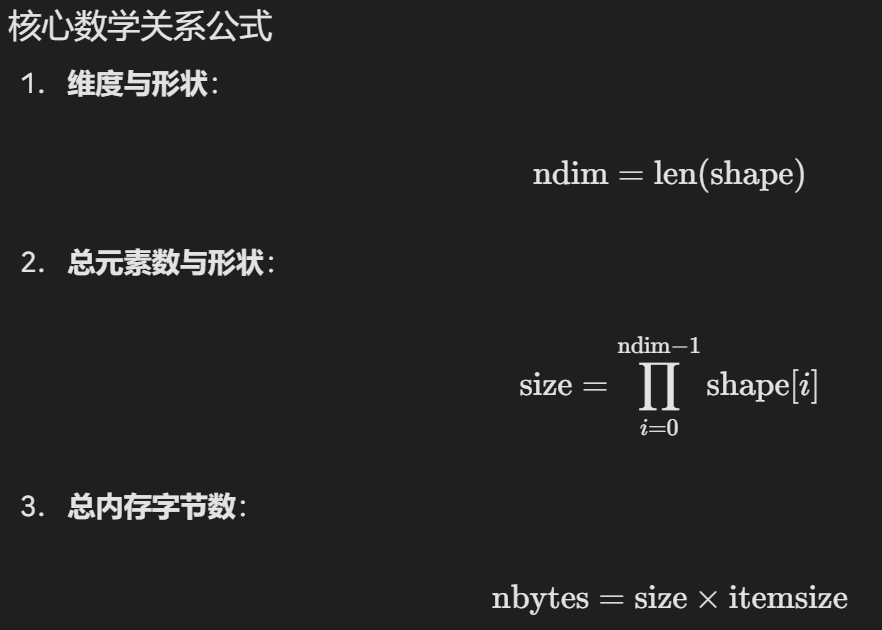

In [39]:
import sys

### 维度与结构属性：ndim、shape、size

#### ndim（Number of Dimensions）—— 维度数 / 秩
定义：数组的轴（Axes）数量，即维度的层数。

- $\text{ndim} = 0$：标量（Scalar，单一数值）

- $\text{ndim} = 1$：向量（Vector，单一序列）

- $\text{ndim} = 2$：矩阵（Matrix，表格、灰度图）

- $\text{ndim} = 3$：三维张量（Tensor，彩色图像 RGB、立体空间）

- $\text{ndim} = 4$：四维张量（深度学习批次：Batch $\times$ Channels $\times$ Height $\times$ Width）

In [40]:
scalar = np.array(42)
vec = np.array([1, 2, 3])
mat = np.array([[1, 2], [3, 4]])
cube = np.zeros((2, 3, 4))

print(scalar.ndim)  # 输出: 0
print(vec.ndim)     # 输出: 1
print(mat.ndim)     # 输出: 2
print(cube.ndim)    # 输出: 3

0
1
2
3


### shape（形状）—— 各轴的长度元组

定义：以 Python tuple 的形式返回数组在每个维度上的长度（元素个数）。

重要特性：元组的长度等于 ndim，即 $\operatorname{len}(\text{shape}) == \text{ndim}$。

In [41]:
a = np.zeros((3, 5))
print(a.shape)  # 输出: (3, 5) -> 表示第 0 轴（行）有 3 个元素，第 1 轴（列）有 5 个元素

(3, 5)


### size（元素总数）
定义：数组中包含的所有数据项的总和。

计算逻辑：等于 shape 元组中所有维度的乘积。

In [42]:
tensor = np.ones((2, 3, 4))
print(tensor.shape)  # (2, 3, 4)
print(tensor.size)   # 2 * 3 * 4 = 24

(2, 3, 4)
24


> size 是数组进行 reshape() 变换的核心依据：重塑前后的数组必须满足 $\text{size}_{\text{原}} == \text{size}_{\text{新}}$。

In [44]:
arr = np.arange(12)  # size = 12
arr_2d = arr.reshape(3, 4)  # 3 * 4 = 12, 合法
print(arr_2d)
arr_3d = arr.reshape(2, 2, 3)  # 2 * 2 * 3 = 12, 合法
print(arr_3d)

# arr.reshape(5, 2)  # 5 * 2 = 10 != 12, 抛出 ValueError

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 类型与内存属性：dtype、itemsize、nbytes

#### dtype（Data Type）—— 元素数据类型

定义：描述数组中单个元素的数据类型及字节存储方案。

特性：NumPy 数组是同质（Homogeneous）的，所有元素共享相同的类型，这使得底层 C 代码能以极高的效率进行连续内存寻址。

| 分类 | 常见类型 | 别名 / 简写 | 单元素字节数 | 取值范围 / 用途 |
|---|---|---|---:|---|
| 布尔 | `np.bool_` | `'?'`, `'bool'` | 1 字节 | `True / False`，常用于掩码 |
| 有符号整数 | `np.int8` | `'i1'` | 1 字节 | `[-128, 127]` |
| 有符号整数 | `np.int16` | `'i2'` | 2 字节 | `[-32768, 32767]` |
| 有符号整数 | `np.int32` | `'i4'` | 4 字节 | 约 `±2.1 × 10^9` |
| 有符号整数 | `np.int64` | `'i8'` | 8 字节 | 常用 64 位整数类型 |
| 无符号整数 | `np.uint8` | `'u1'` | 1 字节 | `[0, 255]`，数字图像 RGB 常用类型 |
| 浮点数 | `np.float16` | `'f2'` | 2 字节 | 半精度浮点，深度学习混合精度训练常见 |
| 浮点数 | `np.float32` | `'f4'` | 4 字节 | 单精度浮点，深度学习主流类型 |
| 浮点数 | `np.float64` | `'f8'` | 8 字节 | 双精度浮点，NumPy 科学计算常见默认浮点类型 |
| 复数 | `np.complex128` | `'c16'` | 16 字节 | 双精度实部 8 字节 + 双精度虚部 8 字节 |

In [45]:
# 查看与转换数据类型
arr = np.array([1, 2, 3])
print(arr.dtype)  # int64 或 int32

# 通过 astype() 转换类型（返回一个副本）
arr_float = arr.astype(np.float32)
print(arr_float.dtype)  # float32

int64
float32


### itemsize（单元素内存大小）

定义：数组中每一个元素所占用的字节数（Bytes）。

与 dtype 的关系：

$$\text{itemsize} = \frac{\text{类型位宽（Bits）}}{8}$$

例如：float64 是 64 位浮点数，占 $64 \div 8 = 8$ 字节，其 itemsize = 8。

例如：int8 是 8 位整数，占 $8 \div 8 = 1$ 字节，其 itemsize = 1。

In [46]:
x = np.array([1, 2, 3], dtype=np.int16)
print(x.itemsize)  # 2 (16 bits / 8 = 2 bytes)

y = np.array([1.0, 2.0], dtype=np.float64)
print(y.itemsize)  # 8 (64 bits / 8 = 8 bytes)

2
8


### nbytes（数据区总内存大小）

定义：数组中所有数据元素占用的总字节数。
计算公式：
$$\text{nbytes} = \text{size} \times \text{itemsize}$$

In [47]:
data = np.ones((1000, 1000), dtype=np.float64)
# size = 1,000,000 个元素
# itemsize = 8 字节
print(data.nbytes)  # 8,000,000 字节 ≈ 7.63 MB

# 转化为 MB 查看
print(f"{data.nbytes / (1024 ** 2):.2f} MB")  # 7.63 MB

8000000
7.63 MB


# 张量的形状

## reshape() 的精妙机制与底层本质

reshape() 用于在保持元素总数不变的前提下，重新排列数组的轴结构。

### 基础原则：元素守恒定律

进行形状重塑时，原形状的元素乘积与新形状的元素乘积必须绝对相等：

$$\prod_{i=0}^{m-1} \text{shape}_{\text{old}}[i] = \prod_{j=0}^{n-1} \text{shape}_{\text{new}}[j] = \text{size}$$

In [48]:
arr = np.arange(12)  # size = 12
print(arr)

r1 = arr.reshape(3, 4)    # 3 * 4 = 12 (合法)
print(r1)

r2 = arr.reshape(2, 2, 3) # 2 * 2 * 3 = 12 (合法)
print(r2)

# arr.reshape(5, 2)       # 5 * 2 = 10 != 12 (抛出 ValueError: cannot reshape...)

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### -1 自动推导功能

当已知重塑后的某些维度大小，不愿手动计算剩余维度时，可将该位置传入 -1，NumPy 会根据元素守恒公式自动计算补全：
$$\text{shape}[-1] = \frac{\text{size}}{\prod_{k \neq -1} \text{shape}[k]}$$

In [49]:
x = np.arange(24)  # size = 24

# 1. 想要固定有 4 列，行数自动推导
a = x.reshape(-1, 4)
print(a.shape)  # 输出: (6, 4) -> 24 / 4 = 6

# 2. 想要固定有 2 个块、3 个行，列数自动推导
b = x.reshape(2, 3, -1)
print(b.shape)  # 输出: (2, 3, 4) -> 24 / (2 * 3) = 4

# 3. 极速将多维数组展平为一维（Flatten）
c = b.reshape(-1)
print(c.shape)  # 输出: (24,)

(6, 4)
(2, 3, 4)
(24,)


> 约束条件：一个 reshape() 表达式中只能出现一次 -1。若出现多个 -1，方程会出现多解，NumPy 会直接抛出异常。

### 底层本质：reshape 不等于复制！

这是 NumPy 高效的核心秘密：reshape 默认创建的是视图（View），而非数据的深拷贝（Copy）！

In [50]:
orig = np.array([1, 2, 3, 4, 5, 6])
reshaped = orig.reshape(2, 3)

# 修改 reshaped 中的一个元素
reshaped[0, 0] = 999

# 观察原数组 orig
print(orig)
# 输出: [999   2   3   4   5   6] -> 原数组同步被改变！

[999   2   3   4   5   6]


#### 为什么不需要复制？

NumPy 数组利用 Strides（步长） 来遍历内存。重塑数组时，NumPy 仅修改了数组头部的 shape 和 strides 元数据，指向底层数据的指针没有变化。

> 当数组经过转置（如 arr.T）导致其在内存中不再是 C 连续存储（C-Contiguous）时，如果强行调用 reshape()，NumPy 无法通过简单修改步长实现视图，此时会被迫退化为数据拷贝。

## 增减维度：np.newaxis、expand_dims()、squeeze()

在深度学习模型推理时，经常需要为单个样本增加批次维度（如从 (H, W, C) 变为 (1, H, W, C)），或在模型输出后消除多余的长度为 $1$ 的维度。

### 升维：np.newaxis

定义：np.newaxis 是 Python 中 None 的别名。

用法：在切片索引中插入 np.newaxis，会在对应轴位置插入一个长度为 $1$ 的新维度。

In [52]:
x = np.array([1, 2, 3])  # shape: (3,)

# 1. 变为行向量 (1, 3)
row_vec = x[np.newaxis, :]
print(row_vec.shape)  # 输出: (1, 3)
print(row_vec)

# 2. 变为列向量 (3, 1)
col_vec = x[:, np.newaxis]
print(col_vec.shape)  # 输出: (3, 1)
print(col_vec)

# 3. 亦可直接简写为 None（完全等价）
col_vec_alt = x[:, None]
print(col_vec_alt.shape)  # 输出: (3, 1)
print(col_vec_alt)


(1, 3)
[[1 2 3]]
(3, 1)
[[1]
 [2]
 [3]]
(3, 1)
[[1]
 [2]
 [3]]


## 升维：np.expand_dims()

语法：np.expand_dims(a, axis)

特点：函数式风格，相比切片语法糖，代码可读性更高，支持传入元组一次性在多个轴上升维。

In [ ]:
arr = np.zeros((3, 4))  # 初始 shape: (3, 4)

# 1. 在第 0 轴升维（常用于添加 Batch 维度）
b0 = np.expand_dims(arr, axis=0)
print(b0.shape)  # 输出: (1, 3, 4)

# 2. 在最后一个轴升维
b_last = np.expand_dims(arr, axis=-1)
print(b_last.shape)  # 输出: (3, 4, 1)

# 3. 一次在多个轴上升维
b_multi = np.expand_dims(arr, axis=(0, 2))
print(b_multi.shape)  # 输出: (1, 3, 1, 4)

## 降维/挤压：squeeze()

定义：移除数组中所有长度等于 $1$ 的多余维度（也称退化维度）。

核心作用：从张量中“脱掉”多余的单层中括号。

In [ ]:
data = np.zeros((1, 3, 1, 4))

# 1. 默认压缩所有长度为 1 的轴
sq1 = data.squeeze()
print(sq1.shape)  # 输出: (3, 4)

# 2. 针对指定轴进行压缩（更安全，推荐工程中使用）
sq2 = data.squeeze(axis=0)
print(sq2.shape)  # 输出: (3, 1, 4)

# 3. 错误挤压抛错演示：若指定轴的长度不为 1，则无法压缩
# data.squeeze(axis=1)  # 抛出 ValueError: cannot select an axis to squeeze out which has size not equal to one

# Stride：理解数组底层内存

在 NumPy 的性能设计中，Strides（步长） 是最隐秘却最核心的“黑魔法”。它是连接物理内存中一维连续数据与上层多维张量逻辑视图的几何桥梁。

搞懂了 Strides，你就能彻底理解：

- 为什么矩阵转置（.T）和切片是瞬间完成的（$O(1)$ 零内存拷贝）？

- 为什么转置后的数组调用 reshape() 会触发数据复制？

- 为什么按行遍历和按列遍历的速度可以相差数十倍（CPU Cache 缓存命中率）？

### Strides 到底是什么？

核心定义

strides 是一个元组，表示沿着数组的各个维度（轴）向前移动 $1$ 个步长（即索引加 $1$）时，在物理内存中需要跨越的【字节数（Bytes）】。

⚠️ 关键避坑（NumPy vs PyTorch）：

- 在 NumPy 中，arr.strides 是以 字节（Bytes） 为单位的。

- 在 PyTorch 中，tensor.stride() 是以 元素个数（Elements） 为单位的。

- 两者关系为：$\text{NumPy Stride} = \text{PyTorch Stride} \times \text{itemsize}$。
![img2](./src/chapter02.png)

在上述矩阵中：

- 沿着第 1 轴（列，横向）从 1.0 移动到 2.0：只需要跨过 $1$ 个元素 $= 8$ 字节。

- 沿着第 0 轴（行，纵向）从 1.0 移动到 4.0：需要跨过整整一行（$3$ 个元素）$= 3 \times 8 = 24$ 字节。

- 因此该矩阵的 strides 即为：(24, 8)。

# 转置与维度交换

## 核心底座——理解轴（Axis）与内存视图（View）

### 什么是“轴”（Axis）？

NumPy 数组的维度由轴（Axis）定义：

- 0 维（标量）：没有轴，shape = ()

- 1 维（向量）：1 个轴，axis=0，shape = (N,)

- 2 维（矩阵）：2 个轴，axis=0（行），axis=1（列），shape = (行数, 列数)

- 3 维（张量）：3 个轴，常见如 shape = (层/批次, 高度, 宽度)，对应的轴索引分别为 0, 1, 2

### 转置与重塑（Reshape）的根本区别

reshape：按照内存线性排布重新切分切片，不改变元素的相对空间对应关系。

转置/维度交换：改变轴的几何方向。原本沿某个轴移动的步长，现在沿另一个轴移动。

### 底层原理：视图（View）与步长（Strides）

在 NumPy 中，绝大多数转置操作不会拷贝内存，而是返回原数组的一个视图（View）。

原理：仅修改数组的元数据（shape 和 strides），数据在内存中依然保持原样存放。

影响：

- 极速高效：常数级时间复杂度 $\mathcal{O}(1)$。

- 联动修改：修改转置后的数组，原数组的值也会改变。

- 内存不连续性：转置后的数组通常不再满足 C 连续性（C-contiguous），在传给某些 C/CUDA 底层库或 PyTorch 时，可能需要调用 .copy() 或 np.ascontiguousarray()。

## .T 属性——经典转置

最简便、最直观的转置方式。在二维情况下，它就是线性代数中的矩阵转置 $A^T$。

**行为规则**

- 二维数组：交换行列，shape: (M, N) -> (N, M)。

- 高维数组：逆序翻转所有轴。若输入维度形状为 $(d_0, d_1, \dots, d_{n-1})$，转置后变为 $(d_{n-1}, \dots, d_1, d_0)$。

- 一维数组：保持不变！因为一维向量没有“列”的概念，形状仍为 $(N,)$。

In [53]:

# 1. 二维矩阵
a = np.array([[1, 2, 3],
              [4, 5, 6]])
print("原形状:", a.shape)  # (2, 3)
print("a.T:\n", a.T)
print("新形状:", a.T.shape)  # (3, 2)

# 2. 一维向量避坑
v = np.array([1, 2, 3])
print("v.T 与原数组完全相同:", v.T.shape)  # 仍然是 (3,)
# 如果需要行列互换，应先升维：
v_col = v[:, None]  # shape: (3, 1)
print("列向量转置为行向量:", v_col.T.shape)  # (1, 3)

# 3. 三维数组逆序
tensor = np.ones((2, 3, 4))
print("高维 .T 形状:", tensor.T.shape)  # (4, 3, 2)

原形状: (2, 3)
a.T:
 [[1 4]
 [2 5]
 [3 6]]
新形状: (3, 2)
v.T 与原数组完全相同: (3,)
列向量转置为行向量: (1, 3)
高维 .T 形状: (4, 3, 2)


## transpose()——全能的维度重排

最通用、最自由的维度重排工具。既可以作为实例方法 arr.transpose(*axes)，也可以作为函数 np.transpose(arr, axes)。

### 参数语法

arr.transpose(axes=None)

- axes：一个由整数组成的元组或列表，表示目标维度的排列顺序。

- 如果不传参数 axes=None，其效果等同于 .T（将所有维度逆序）。

### 理解 axes=(p0, p1, p2, ...) 的含义

参数里的索引值是原维度的编号。

axes=(1, 0, 2) 意味着：

- 新数组的第 0 维来自原数组的第 1 维；

- 新数组的第 1 维来自原数组的第 0 维；

- 新数组的第 2 维来自原数组的第 2 维。

In [54]:
# 创建一个 3D 数组，形状 (2, 3, 4)
# 对应维度索引: 轴0=2, 轴1=3, 轴2=4
arr = np.arange(24).reshape(2, 3, 4)
arr

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [55]:
# 需求：将第 0 维与第 1 维调换，第 2 维保持不变
res = arr.transpose(1, 0, 2)
print("转置后形状:", res.shape)  # (3, 2, 4)
res

转置后形状: (3, 2, 4)


array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

### swapaxes()——精准对调两轴

当你只关心交换特定的某两个维度，而希望其他所有维度都保持原有相对顺序时，swapaxes() 是最清晰、最不易出错的选择。

#### 参数语法

np.swapaxes(a, axis1, axis2) 或 a.swapaxes(axis1, axis2)

- axis1：要交换的第一个轴。

- axis2：要交换的第二个轴。

#### 与 transpose() 的逻辑对比

假设数组形状为 5 维：(d0, d1, d2, d3, d4)。

若要交换第 1 维和第 3 维：

- 使用 transpose：必须写出所有维度的完整序列 arr.transpose(0, 3, 2, 1, 4)（容易数错漏项）。

- 使用 swapaxes：只需指定 arr.swapaxes(1, 3)，意图明确且不易出错。

In [56]:
# 模拟批量图像数据：(Batch=32, Height=256, Width=256, Channel=3)
batch_imgs = np.zeros((32, 256, 256, 3))

# 仅交换高度和宽度（做几何对称处理等）
swapped = batch_imgs.swapaxes(1, 2)
print("交换 H 和 W 后的形状:", swapped.shape)  # (32, 256, 256, 3)

# 交换 Batch 与 Channel
swapped_bc = batch_imgs.swapaxes(0, 3)
print("交换 Batch 和 Channel 后的形状:", swapped_bc.shape)  # (3, 256, 256, 32)

交换 H 和 W 后的形状: (32, 256, 256, 3)
交换 Batch 和 Channel 后的形状: (3, 256, 256, 32)


## moveaxis()——维度的“剪切”与“粘贴”

现代 NumPy / PyTorch 中最推荐的轴移动工具。它表示将某一个（或几个）轴移动到指定的新位置，其余轴按原相对顺序平移递补。

### 参数语法

np.moveaxis(a, source, destination)

- source：需要被移动的轴的原位置（可为标量或列表/元组）。

- destination：目标插槽位置（可为标量或列表/元组）。

- 支持负数索引（如 -1 表示最后一个维度）。

### 为什么需要 moveaxis？

考虑经典深度学习场景：

OpenCV / 常用图片库格式：HWC 形状为 (Height, Width, Channel)。

PyTorch 卷积层期望输入：CHW 形状为 (Channel, Height, Width)。

任务本质：把通道轴（原位置 2 或 -1）“剪切”出来，“粘贴”到最前面（位置 0）。

- 用 transpose：np.transpose(img, (2, 0, 1))

- 用 moveaxis：np.moveaxis(img, -1, 0)（语义极度清晰，表达“把最后一维移到第0维”）。

In [57]:
# 模拟单张图片 (H, W, C) -> (480, 640, 3)
img = np.zeros((480, 640, 3))

# 将最后一维 (C) 移动到最前 (第 0 维)
img_chw = np.moveaxis(img, source=-1, destination=0)
print("HWC 转 CHW 形状:", img_chw.shape)  # (3, 480, 640)

# 支持多个轴同时移动
# (N, H, W, C) -> (N, C, H, W)
batch = np.zeros((16, 480, 640, 3))
batch_chw = np.moveaxis(batch, source=3, destination=1)
print("NHWC 转 NCHW 形状:", batch_chw.shape)  # (16, 3, 480, 640)

HWC 转 CHW 形状: (3, 480, 640)
NHWC 转 NCHW 形状: (16, 3, 480, 640)


# 元素运算 vs 矩阵运算

在 NumPy、PyTorch 以及通用科学计算中，最容易让初学者写出隐蔽 Bug 的地方就是混淆了元素运算与矩阵运算。一个简单的乘号 * 与矩阵乘号 @ 的差异，往往会导致模型输出维度完全失控或逻辑彻底偏离。

## 元素运算 vs 矩阵运算的分野

| 比较维度      | 元素运算（Element-wise）   | 矩阵运算（Matrix Multiplication）         |
| --------- | -------------------- | ----------------------------------- |
| 数学符号      | 哈达玛积 \(A \odot B\)   | 矩阵乘法 \(AB\) 或 \(A \times B\)        |
| Python 算子 | `*`、`+`、`-`、`/`、`**` | `@`、`np.matmul()`、`np.dot()`        |
| 计算逻辑      | 相同位置的元素**一对一独立计算**   | “行乘列求和”，元素之间**交叉组合累加**              |
| 形状约束      | 形状必须完全相同，或满足**广播机制** | **内侧维度必须严格相等**：\((M,K)\times(K,N)\) |
| 输出形状      | 与输入（广播后）形状一致         | 由外侧维度决定：\((M,N)\)                   |
| 几何意义      | 缩放、加权、掩码过滤、逐点非线性激活   | 空间变换、投影、基底变换、特征混合                   |

## 元素级运算（Element-wise）深度剖析

### 核心定义

元素级运算指仅在张量的对应坐标位置上单独执行标量运算，各位置互不干扰。对于矩阵 $A, B \in \mathbb{R}^{M \times N}$，其逐元素乘积（Hadamard 积）定义为：

$$C_{ij} = A_{ij} \cdot B_{ij}$$

In [58]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

# 1. 逐元素乘法 (Element-wise Product)
print("A * B:\n", A * B)
# 输出:
# [[ 1*5,  2*6],
#  [ 3*7,  4*8]] => [[ 5, 12], [21, 32]]

# 2. 其它常见的逐元素运算
print("A + B:\n", A + B)
print("A ** 2:\n", A ** 2)
print("np.sin(A):\n", np.sin(A))

A * B:
 [[ 5 12]
 [21 32]]
A + B:
 [[ 6  8]
 [10 12]]
A ** 2:
 [[ 1  4]
 [ 9 16]]
np.sin(A):
 [[ 0.84147098  0.90929743]
 [ 0.14112001 -0.7568025 ]]


## 结合广播机制（Broadcasting）的元素运算

如果两个数组的形状不完全相同，只要它们满足广播规则（从后向前对齐，维度要么相等，要么其中一个为 1），就会自动沿大小为 1 的轴复制扩张，然后再进行逐元素运算：

In [59]:
# A: shape (2, 3)
A = np.array([[1, 2, 3],
              [4, 5, 6]])
# bias: shape (1, 3) -> 自动沿 axis=0 广播到 (2, 3)
bias = np.array([10, 20, 30])

print(A + bias)
# 输出:
# [[11, 22, 33],
#  [14, 25, 36]]

[[11 22 33]
 [14 25 36]]


## 深度学习典型应用

- 激活函数：ReLU、Sigmoid、GELU 等均为逐元素非线性变换。

- Mask 掩码操作：Attention 中的 scores * mask，用 0 屏蔽无用特征。

- 逐像素归一化：图像除以 255.0、减均值除方差。

## 矩阵乘法（MatMul）基础规则

### 维度契合法则（核心铁律）

矩阵乘法能够发生的前提是：左矩阵的列数等于右矩阵的行数（即“内侧维度相等”）。

$$\underbrace{A}_{(M \times K)} \times \underbrace{B}_{(K \times N)} = \underbrace{C}_{(M \times N)}$$

- 内侧维度 $K$：必须完全一致，是求和抵消的轴。

- 外侧维度 $M, N$：直接决定了结果矩阵的最终行数和列数。

- 计算公式为向量点积的和：

$$C_{ij} = \sum_{k=1}^{K} A_{ik} B_{kj}$$

在现代 Python（Python 3.5+）及 NumPy 中：

- 推荐使用 @ 运算符，语义鲜明且与数学记号高度吻合。

- 函数写法为 np.matmul(A, B)。

In [60]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])  # shape: (2, 3)

B = np.array([[1, 2],
              [3, 4],
              [5, 6]])     # shape: (3, 2)

# 内侧维度均为 3，结果维度为 (2, 2)
C = A @ B
print("矩阵乘法 A @ B:\n", C)
# C[0, 0] = 1*1 + 2*3 + 3*5 = 22
# C[0, 1] = 1*2 + 2*4 + 3*6 = 28
# C[1, 0] = 4*1 + 5*3 + 6*5 = 49
# C[1, 1] = 4*2 + 5*4 + 6*6 = 64

矩阵乘法 A @ B:
 [[22 28]
 [49 64]]


## 一维向量的特殊规则（Vector Dot Product）

NumPy 对一维向量做 @ 时有特殊的自动处理机制：

两个一维向量：计算内积（点积），返回标量。

In [61]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])
print(u @ v)  # 1*4 + 2*5 + 3*6 = 32 (标量)

32


## 批量矩阵乘法（Batch Matrix Multiplication, BMM）

### 为什么需要 Batch Matrix Multiplication？

在实际工业级模型中，样本绝不会单条处理，而是打成批次（Batch）并行计算。
例如：

- 批量文本序列：(Batch, Seq_Len, Hidden_Dim)

- 批量图像特征：(Batch, Channels, HW)

如果对 Batch 中的每个样本都写 for 循环做二维矩阵乘法，会导致计算无法充分利用 GPU/CPU 向量化指令。批量矩阵乘法（BMM）允许我们在单个算子内同时对一组矩阵执行乘法。

在多维张量中，最后两个轴被视为待相乘的二维矩阵，前面的所有轴都被视为批次维度（Batch Dimensions）。

$$\underbrace{A}_{(B, M, K)} @ \underbrace{B}_{(B, K, N)} \to \underbrace{C}_{(B, M, N)}$$

In [ ]:

batch_size = 8
M, K, N = 4, 16, 8

A = np.random.randn(batch_size, M, K)  # (8, 4, 16)
B = np.random.randn(batch_size, K, N)  # (8, 16, 8)

# 批量执行 8 次 (4, 16) @ (16, 8) 的矩阵乘
C = A @ B
print("BMM 结果形状:", C.shape)  # 输出: (8, 4, 8)

### 结合广播的批量矩阵乘法（Broadcasting BMM）

np.matmul（或 @）的一大精髓是：前面的批次维度支持标准广播机制！只要后两个维度满足内侧匹配，前面的批次维度就可以自动扩充。

#### 场景 1：单个权重矩阵作用于整个批次

输入 $X$ 包含批次，但权重矩阵 $W$ 是共享的：

In [62]:
X = np.random.randn(32, 100, 64)  # (Batch=32, Tokens=100, Dim=64)
W = np.random.randn(64, 128)      # 共享全连接权重 (64, 128)

# W 自动扩维为 (1, 64, 128) 并广播到 32 份
out = X @ W
print("输出形状:", out.shape)  # (32, 100, 128)

输出形状: (32, 100, 128)


#### 场景 2：Transformer 多头自注意力机制（Multi-Head Attention）

这是深度学习中最具代表性的 BMM 经典案例：

- $Q$（Query）形状：$(B, H, S_q, d_k)$

$K$（Key）形状：$(B, H, S_k, d_k)$

计算注意力权重得分：

$$Attention\_Scores = Q \times K^T$$

In [63]:
B, H, S, d_k = 16, 8, 128, 64

Q = np.random.randn(B, H, S, d_k)
K = np.random.randn(B, H, S, d_k)

# 注意：利用我们上节课学的转置，将最后两维翻转 (B, H, S, d_k) -> (B, H, d_k, S)
K_T = K.swapaxes(-1, -2)

# 执行 BMM: (B, H, S, d_k) @ (B, H, d_k, S) -> (B, H, S, S)
scores = (Q @ K_T) / np.sqrt(d_k)

print("Attention Scores 形状:", scores.shape)  # (16, 8, 128, 128)

Attention Scores 形状: (16, 8, 128, 128)


# Broadcasting

广播机制（Broadcasting）是 NumPy 和 PyTorch 处理不同形状数组进行逐元素（Element-wise）运算的核心技术。它让不同维度的张量在无需显式复制数据的前提下，自动协同完成对齐与计算。

## 为什么需要广播

在没有广播机制前，如果让一个形状为 (3, 3) 的矩阵与一个长度为 3 的向量相加，必须手动调用 np.tile() 或循环拷贝数据，将其扩展为 (3, 3)。这会带来两大缺陷：

- 内存浪费：显式拷贝会申请全新的内存空间，如果处理数百万级参数的大张量，内存消耗会成倍暴增。

- 计算低效：额外的内存分配与数据移动会显著降低 CPU/GPU 的缓存命中率与执行速度。

广播的底层本质：步长为 0（Zero-Copy）
广播在物理内存上不复制任何数据。当某个维度的尺寸从 1 广播到 N 时，NumPy/PyTorch 仅修改了数组元数据中的 步长（strides），将该轴的步长设为 0。这意味着指针在该维度移动时，始终读取同一个物理内存地址，以 $O(1)$ 的内存开销实现了逻辑上的全量扩展。

In [64]:
import numpy as np

a = np.array([1, 2, 3])          # shape: (3,)
b = 10                           # 标量广播为 (3,)
print(a + b)                     # 输出: [11 12 13]，无显式内存拷贝

[11 12 13]


# Axis与聚合计算

在 NumPy、PyTorch 等科学计算与深度学习框架中，axis（在 PyTorch 中称为 dim）是最基础、最频繁使用但同时也是最容易让初学者产生认知混乱的概念。

搞清楚 axis 的本质，不仅能彻底解决“axis=0 到底按行还是按列”的世纪难题，还能帮助你在计算 Softmax、归一化（BatchNorm / LayerNorm）以及各类高维损失函数时游刃有余。

## axis 的本质——“消除/坍缩”心智模型

初学者最容易陷入的误区是：死记“axis=0 是列，axis=1 是行”。这种记忆方法在二维时尚可勉强应付，一旦扩展到三维、四维（如 (Batch, Channel, Height, Width)），大脑就会彻底当机。

1. 核心铁律：沿着该轴进行“挤压与消除”

核心法则：
对哪一个 axis 执行聚合运算（如求和、均值、极值），哪一个维度就会在结果的 shape 中被“折叠消除”（坍缩为标量或消失）。

- 假设数组的形状为：$(d_0, d_1, d_2, d_3)$

- 若指定 axis=0：结果形状变为 $(d_1, d_2, d_3)$，第 0 维被抹去。

若指定 axis=2：结果形状变为 $(d_0, d_1, d_3)$，第 2 维被抹去。

- 若指定 axis=(1, 2)：结果形状变为 $(d_0, d_3)$，第 1 维和第 2 维同时被折叠。
2. 括号嵌套视角（从物理存储理解）

从 Python 列表嵌套（或内存层级）的角度看：

- axis=0：代表最外层的那对中括号 [ ]（包含几个大的元素块）。

- axis=1：代表次外层的那对中括号。

- axis=-1：代表最内层的一对中括号（直接包着标量数字的那一层）。

沿着 axis=k 聚合，本质就是把第 $k$ 层中括号里的对应元素拉出来逐一执行操作并合并

## 二维矩阵中的 axis 几何剖析

设有一个形状为 $(3, 4)$ 的矩阵 $A$（3 行 4 列）：

$$A = \begin{bmatrix} 1 & 2 & 3 & 4 \\ 5 & 6 & 7 & 8 \\ 9 & 10 & 11 & 12 \end{bmatrix}$$

其维度定义为：

- axis=0：行索引方向（纵向向下，长度为 3）。

- axis=1：列索引方向（横向向右，长度为 4）。

axis=0 的物理动作:

- 动作：沿着纵向（跨越不同的行）扫过去，把同一列上的元素压扁累加。

- 维度变化：$(3, 4) \xrightarrow{axis=0} (4,)$

- 直观效果：3 行被“拍扁”成了 1 行，保留了 4 列，俗称“按列统计（每一列得到一个结果）”。

$$\text{Result} = \begin{bmatrix} 1+5+9 & 2+6+10 & 3+7+11 & 4+8+12 \end{bmatrix} = \begin{bmatrix} 15 & 18 & 21 & 24 \end{bmatrix}$$

axis=1 的物理动作

- 动作：沿着横向（跨越不同的列）扫过去，把同一行上的元素压扁累加。

- 维度变化：$(3, 4) \xrightarrow{axis=1} (3,)$

- 直观效果：4 列被“压扁”成了 1 列，保留了 3 行，俗称“按行统计（每一行得到一个结果）”。

$$\text{Result} = \begin{bmatrix} 1+2+3+4 \\ 5+6+7+8 \\ 9+10+11+12 \end{bmatrix} \xrightarrow{\text{展平}} \begin{bmatrix} 10 & 26 & 42 \end{bmatrix}$$

## 核心聚合算子实战详解

所有的聚合算子都严格遵循上述“维度消除”逻辑。

In [66]:
arr = np.array([
    [10, 20, 5],
    [30, 40, 60]
])  # shape: (2, 3)

In [68]:
# 1. 全局求和 (axis=None, 默认)
print(arr.sum())        # 165 (标量)

# 2. 沿着 axis=0 (折叠行，输出 3 个列求和)
print(arr.sum(axis=0))  # [10+30, 20+40, 5+60] => [40, 60, 65]，shape: (3,)

# 3. 沿着 axis=1 (折叠列，输出 2 个行求和)
print(arr.sum(axis=1))  # [10+20+5, 30+40+60] => [35, 130]，shape: (2,)

165
[40 60 65]
[ 35 130]


In [69]:
# 数学逻辑即沿指定轴累加后除以该轴的长度 N：

print(arr.mean(axis=0))  # [40/2, 60/2, 65/2] => [20. , 30. , 32.5]
print(arr.mean(axis=1))  # [35/3, 130/3]       => [11.66666667, 43.33333333]

[20.  30.  32.5]
[11.66666667 43.33333333]


In [70]:
# 沿着指定轴扫描，挑选出最大值或最小值：

# 每列的最大值 (消除第 0 轴)
print(arr.max(axis=0))  # [30, 40, 60]

# 每行的最大值 (消除第 1 轴)
print(arr.max(axis=1))  # [20, 60]

[30 40 60]
[20 60]


In [72]:
# argmax 不返回最大值本身，而是返回最大值在被消除轴上的下标索引（Index）。

# 易错注意：返回的不是坐标元组，而是整数索引；且运算同样会消除指定轴。

arr = np.array([[10, 20,  5],
                [30, 40, 60]])

# axis=0：沿纵向看，每列最大值所在的行号 (0 或 1)
# 列 0: 30 在第 1 行；列 1: 40 在第 1 行；列 2: 60 在第 1 行
print(arr.argmax(axis=0))  # 输出: [1, 1, 1]，shape: (3,)

# axis=1：沿横向看，每行最大值所在的列号 (0, 1, 2)
# 行 0: 最大值 20，在第 1 列
# 行 1: 最大值 60，在第 2 列
print(arr.argmax(axis=1))  # 输出: [1, 2]，shape: (2,)

[1 1 1]
[1 2]


在深度学习分类任务中，模型输出经过分类头后的概率 logits 形状为 (Batch_Size, Num_Classes)，获取预测类别正是通过 logits.argmax(axis=-1) 取得每一行最大概率对应的类别编号。

## keepdims=True 的关键作用与广播机制协同

### 为什么会有 keepdims？

默认情况下，keepdims=False。只要执行了聚合操作，被指定的轴就会彻底从形状元组中剔除：

$$(M, N) \xrightarrow{\text{axis=1}} (M,)$$

这样一来，原先的二维矩阵被降阶为了一维向量。这在后续需要与原矩阵做广播运算（Broadcasting）时，会引发严重问题！

### 惨烈踩坑案例：数据中心化（减均值）

假设我们要对每个样本（每一行）进行零均值化：$X_{\text{norm}} = X - \mu_{\text{row}}$

In [74]:
X = np.array([
    [1., 2., 3.],
    [4., 5., 6.]
])  # shape: (2, 3)

# 默认 keepdims=False
row_mean = X.mean(axis=1)
print("均值 shape:", row_mean.shape)  # 输出: (2,)
print("均值:", row_mean)


# 试图相减: (2, 3) - (2,)
try:
    res = X - row_mean
    print(res)
except ValueError as e:
    print("报错:", e)

print(res)

均值 shape: (2,)
均值: [2. 5.]
报错: operands could not be broadcast together with shapes (2,3) (2,) 
[[[ 0  1  2  3]
  [12 13 14 15]]

 [[ 4  5  6  7]
  [16 17 18 19]]

 [[ 8  9 10 11]
  [20 21 22 23]]]


### keepdims=True 如何拯救？

当指定 keepdims=True 时：被消除的轴不会消失，而是其尺寸被强制压缩为 1。

$$(M, N) \xrightarrow[\text{keepdims=True}]{\text{axis=1}} (M, 1)$$

In [77]:
print(X)
row_mean_keep = X.mean(axis=1, keepdims=True)
print("保留维度后的 shape:", row_mean_keep.shape)  # (2, 1)
print("保留维度后的均值:", row_mean_keep)

# 执行广播减法: (2, 3) - (2, 1) -> (2, 3)
# (2, 1) 自动复制拉伸为 (2, 3)，每行元素精确减去该行的均值！
norm_X = X - row_mean_keep
print(norm_X)
# [[-1.  0.  1.]
#  [-1.  0.  1.]]

[[1. 2. 3.]
 [4. 5. 6.]]
保留维度后的 shape: (2, 1)
保留维度后的均值: [[2.]
 [5.]]
[[-1.  0.  1.]
 [-1.  0.  1.]]


切片与索引是张量操作的核心基石。在 NumPy 与 PyTorch 中，索引不仅决定了数据的提取方式，更从底层决定了内存机制——是零拷贝、仅改变元数据的**视图（View）**，还是重新申请物理内存的**副本（Copy）**。

---

### 模块一：基础索引与基础切片（Slicing）

基础切片是沿数组轴提取连续或等间距子集的机制，其核心特征是**共享内存（零拷贝视图）**。

**1. 语法规范与参数**
切片通用语法为 `[start:stop:step]`：

* `start`：起始索引（包含），默认从 `0` 开始。
* `stop`：终止索引（不包含），默认到该轴末尾。
* `step`：步长，默认为 `1`。当 `step < 0` 时表示反向逆序提取。

```python
import numpy as np

arr = np.arange(10)  # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print(arr[2:8:2])    # [2, 4, 6] (从 2 到 7，步长 2)
print(arr[::-1])     # [9, 8, 7, 6, 5, 4, 3, 2, 1, 0] (全量逆序)

```

**2. 单元素索引 vs 切片索引（降维陷阱）**

* **单元素索引会降维**：`arr[0]` 会消除该轴，维度减 1。
* **切片索引保留原维度**：`arr[0:1]` 保持原维度数量（尺寸为 1）。

```python
matrix = np.ones((3, 4))
print(matrix[0].shape)     # (4,)  -> 降为 1 维
print(matrix[0:1].shape)   # (1, 4) -> 保持 2 维

```

**3. 底层机制：视图（View）与内存联动**
基础切片不会创建新数据，仅仅修改了数组的 `shape`、`strides` 和起始偏移量（Offset）：

```python
a = np.array([10, 20, 30, 40])
b = a[1:3]           # 视图，b.base is a 为 True
b[0] = 999           # 修改子数组
print(a)             # 输出: [ 10, 999,  30,  40]，原数组被连带修改！

```

---

### 模块二：多维切片（Multidimensional Slicing）

多维数组的切片通过在方括号内使用逗号 `,` 分隔各个轴的切片规则。

**1. 逗号分隔 vs Python 连续括号**

* **推荐**：`arr[0, 1:3]` —— 一次性在 C 底层完成多维跨步寻址。
* **反例**：`arr[0][1:3]` —— 先在 Python 层提取第 0 轴生成中间对象，再对中间对象二次切片，效率极低且无法实现高维协同提取。

**2. 省略号 `...`（Ellipsis）的高效对齐**
省略号用来代替连续的完整冒号 `:`，自动填满未指定的轴。在处理批处理数据（Batch Data）时极其方便：

```python
# 假设是图像张量: (Batch, Channel, Height, Width)
batch_imgs = np.zeros((32, 3, 224, 224))

# 提取所有 Batch、所有 Channel 的第 100 行:
# 写法 A: batch_imgs[:, :, 100, :]
# 写法 B (更优雅，适应不同维度):
slice_row = batch_imgs[..., 100, :]  # 自动匹配前两个轴

```

**3. `np.newaxis` 与 `None` 配合切片**
在切片中插入 `np.newaxis`（或 `None`）可在指定位置虚构一个尺寸为 1 的新轴，常用于广播对齐：

```python
x = np.array([1, 2, 3])       # shape: (3,)
x_col = x[:, np.newaxis]      # shape: (3, 1)

```

---

### 模块三：布尔索引（Boolean Indexing）

布尔索引通过布尔掩码（Mask）对元素进行条件筛选，用于过滤离群点、实现激活函数或构建动态掩码。

**1. 核心流程与平铺降维特性**
通过比较运算符生成布尔数组，再传入原数组取值。若掩码是高维数组，取出的元素会被**自动展平为一维数组**（因为满足条件的元素在物理内存中通常不连续、非等距分布，无法用规则的多维 strides 描述）：

```python
data = np.array([[10, -2, 5],
                 [-8, 14, 0]])

mask = data > 0
# mask:
# [[ True, False,  True],
#  [False,  True, False]]

positives = data[mask]
print(positives)        # 一维数组: [10,  5, 14]

```

**2. 复合条件陷阱：必须使用位运算符与小括号**
Python 的原生 `and`、`or`、`not` 作用于整个对象的布尔求值，无法逐元素向量化。多维数组必须使用按位运算符 `&`、`|`、`~`，且必须用括号明确优先级：

```python
# 错误写法: data > 0 and data < 10 (会抛出 ValueError)
# 错误写法: data > 0 & data < 10   (优先级问题: 先计算 0 & data)
# 正确写法:
filtered = data[(data > 0) & (data < 10)]

```

**3. 掩码原地修改（In-place Modification）**
布尔索引作为右值（读取）时生成**副本**，但作为左值（赋值）时会**直接就地修改原数组**：

```python
# 模拟 ReLU 激活函数：将所有负数清零
data[data < 0] = 0
print(data)
# [[10,  0,  5],
#  [ 0, 14,  0]]

```

---

### 模块四：花式索引（Fancy Indexing / 整数数组索引）

花式索引指使用**整数数组或 Python 列表**作为索引，自由提取任意非等间距位置的数据。

**1. 一维离散抽取**

```python
arr = np.array([10, 20, 30, 40, 50])
indices = [0, 1, 4]
print(arr[indices])  # [10, 20, 50]

```

**2. 多维坐标配对机制（Pairing Rule）**
当传入多个维度的索引数组时，NumPy **不是**取笛卡尔积（网格交叉），而是将它们**成对匹配**：

```python
mat = np.array([[ 0,  1,  2],
                [ 3,  4,  5],
                [ 6,  7,  8]])

# 想要提取 (0, 0) 和 (2, 2) 两个位置的元素:
row_idx = [0, 2]
col_idx = [0, 2]

print(mat[row_idx, col_idx])  # 输出: [0, 8] (严格成对匹配 (0,0) 与 (2,2))

```

**3. 提取子网格（矩形区域）的方式**
如果需要提取第 0、2 行与第 1、2 列相交构成的 $2 \times 2$ 矩阵，必须利用广播机制或 `np.ix_`：

```python
# 方案 A: 通过增加维度广播成网格 (2, 1) 和 (1, 2) -> (2, 2)
sub_grid = mat[[0, 2], :][:, [1, 2]]

# 方案 B: 使用 np.ix_ 构造网格
sub_grid = mat[np.ix_([0, 2], [1, 2])]
print(sub_grid)
# [[1, 2],
#  [7, 8]]

```

---

### 模块五：底层关键——View（视图）vs Copy（副本）

掌握索引是否触发内存拷贝，是避免程序静默 Bug 和显存爆炸的底线准则。

| 索引方式 | 典型语法 | 产生机制 | 内存是否共享 | 修改是否影响原数组 |
| --- | --- | --- | --- | --- |
| **基础切片** | `arr[1:4, :]` | **View** | 共享内存 | **影响** |
| **基础单索引** | `arr[0, 1]` | **View / Scalar** | 共享内存 | **影响** |
| **布尔索引 (读取)** | `arr[arr > 0]` | **Copy** | 独立物理内存 | **不影响** |
| **花式索引 (读取)** | `arr[[0, 2]]` | **Copy** | 独立物理内存 | **不影响** |
| **掩码/花式 (赋值)** | `arr[mask] = 0` | **In-place** | 直接写原内存 | **影响** |

**致命陷阱：链式索引赋值失效（Chained Assignment）**

```python
arr = np.array([1, 2, 3, 4, 5])

# 错误操作:
arr[arr > 3][0] = 999
print(arr)  # 原数组依然是 [1, 2, 3, 4, 5]！

```

*原因分析*：`arr[arr > 3]` 是布尔读取，创建了一个全新的临时 **Copy** 数组，`[0] = 999` 只是修改了这个瞬时销毁的临时变量，原数组丝毫不受影响。必须统一写在同一个方括号内：`arr[np.where(arr > 3)[0][0]] = 999`。

---

### 模块六：深度学习与高频工程场景

**1. 颜色通道逆转（BGR 转 RGB）**
OpenCV 读取的图像默认为 BGR，深度学习模型输入通常为 RGB，直接用步长切片以零拷贝视图转换：

```python
# img shape: (H, W, 3)
img_rgb = img_bgr[..., ::-1]  # 步长为 -1，极速完成通道倒序

```

**2. 分类任务中提取目标类别的预测置信度**
在多分类损失函数（如 Cross Entropy）中，需要提取每个样本在真实 Label 处的预测得分：

```python
batch_size, num_classes = 4, 3
logits = np.random.randn(batch_size, num_classes)
labels = np.array([2, 0, 1, 2])  # 真实类别

# 利用一维向量 + 整数索引成对提取 (0, 2), (1, 0), (2, 1), (3, 2)
target_scores = logits[np.arange(batch_size), labels]

```

**3. NLP 中的 Embedding 查表底层**
深度学习中的词嵌入层 `nn.Embedding(vocab_size, d_model)`，其前向传播计算本质就是一个高维 Fancy Indexing：

```python
embedding_table = np.random.randn(1000, 128)  # 词表大小 1000，特征维度 128
input_tokens = np.array([[12, 45, 99],
                         [8,  23, 701]])     # Batch=2, Seq_len=3

# 输出形状自动变为 (2, 3, 128)，直接通过整数索引完成映射
embedded = embedding_table[input_tokens]

```

---

### 模块七：实战推导自测

请尝试推导以下两段代码的输出，检验对 View 与多维配对的理解：

**题目 1（内存与视图）：**

```python
a = np.arange(6).reshape(2, 3)
b = a[:, 1:]
c = a[:, [1, 2]]
b[0, 0] = 100
c[1, 1] = 200
# 此时 a[0, 1] 和 a[1, 2] 的值分别是多少？

```

**题目 2（索引形状与配对）：**

```python
x = np.ones((4, 5, 6))
idx_row = np.array([0, 2])
idx_col = np.array([1, 3])
# 表达式 x[idx_row, idx_col].shape 会输出什么形状？

```

推导完成后可将结果发在对话框中，我们一起核对。